<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/ML/EDA_ON_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 ! pip install opendatasets

In [2]:
import opendatasets as od

In [3]:
od.download('https://www.kaggle.com/datasets/hesh97/titanicdataset-traincsv')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: g65ashaharier21031
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/hesh97/titanicdataset-traincsv


100%|██████████| 22.0k/22.0k [00:00<00:00, 36.7MB/s]

In [4]:
import numpy as np
import pandas as pd

In [5]:
import os
target_directory = '/home/ebratul/Downloads/kaggle'

# os.walk ব্যবহার করে সেই ডিরেক্টরির সমস্ত ফাইল পথ প্রিন্ট করা
print(f"Directory contents for: {target_directory}\n")
for dirname, _, filenames in os.walk(target_directory):
    for filename in filenames:
        # সম্পূর্ণ ফাইল পথ তৈরি ও প্রিন্ট করা
        full_path = os.path.join(dirname, filename)
        print(full_path)

Directory contents for: /home/ebratul/Downloads/kaggle



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [7]:
df = pd.read_csv("/content/titanicdataset-traincsv/train.csv")

In [8]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
399,400,1,2,"Trout, Mrs. William H (Jessie L)",female,28.0,0,0,240929,12.6500,NaN,S
75,76,0,3,"Moen, Mr. Sigurd Hansen",male,25.0,0,0,348123,7.6500,F G73,S
765,766,1,1,"Hogeboom, Mrs. John C (Anna Andrews)",female,51.0,1,0,13502,77.9583,D11,S
114,115,0,3,"Attalah, Miss. Malake",female,17.0,0,0,2627,14.4583,NaN,C
570,571,1,2,"Harris, Mr. George",male,62.0,0,0,S.W./PP 752,10.5000,NaN,S
712,713,1,1,"Taylor, Mr. Elmer Zebley",male,48.0,1,0,19996,52.0000,C126,S
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
105,106,0,3,"Mionoff, Mr. Stoytcho",male,28.0,0,0,349207,7.8958,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.5500,NaN,S


In [9]:
df.shape

(891, 12)

In [10]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# Categorical Columns
- Survived
- Pclass
- Sex
- SibSp
- Parch
- Embarked

# Numerical columns
- Age
- Fare
- PassengerID

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
df.drop(columns= ['Cabin'], inplace = True)

In [14]:
df['Age'].fillna(df['Age'].mean(), inplace = True)

/tmp/ipython-input-2940318962.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace = True)


In [15]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [16]:
df['Embarked'].fillna('S', inplace = True)

/tmp/ipython-input-1144286666.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna('S', inplace = True)


In [17]:
df['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [18]:
df['Parch'].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


# Changing datatype for the following cols

- survived (c)
- pclass(c)
- sex(c)
- age(i)
- embark(c)

In [19]:
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Age'] = df['Age'].astype('int')
df['Embarked'] = df['Embarked'].astype('category')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    int64   
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(4), float64(1), int64(4), object(2)
memory usage: 52.8+ KB


In [21]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.544332,0.523008,0.381594,32.204208
std,257.353842,13.013778,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,29.000000,0.000000,0.000000,14.454200
75%,668.500000,35.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


out of 891 62% people died


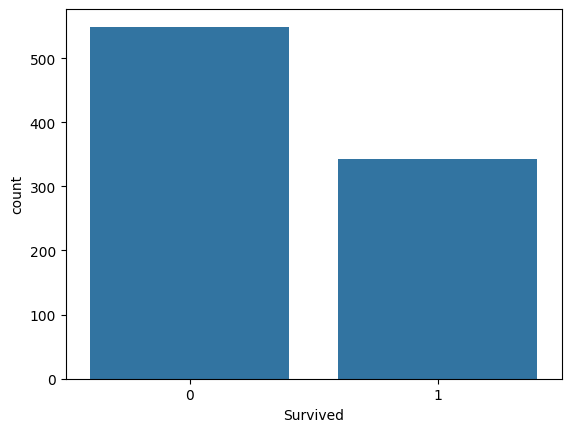

In [22]:
# Univariate Analysis(Survived col)

sb.countplot(x = df['Survived'])
death_percent = round((df['Survived'].value_counts().values[0]/891)*100)
print("out of 891 {}% people died".format(death_percent))

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: count, dtype: float64


<Axes: xlabel='Pclass', ylabel='count'>

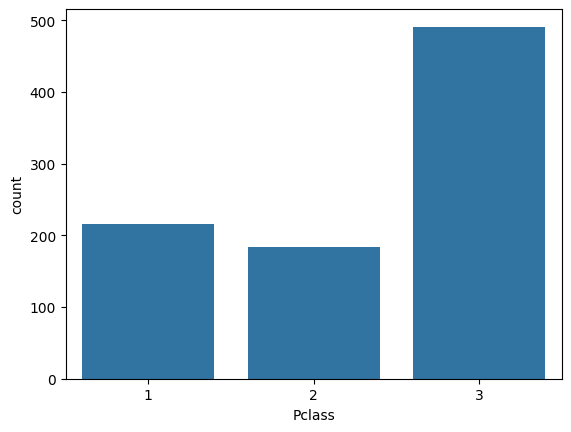

In [23]:
# Pclass column
print((df['Pclass'].value_counts()/891)*100)
sb.countplot(x =df['Pclass'])

Sex
male      577
female    314
Name: count, dtype: int64


<Axes: xlabel='Sex', ylabel='count'>

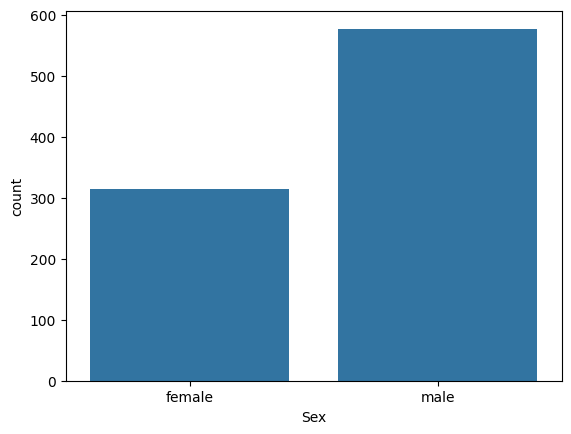

In [24]:
print(df['Sex'].value_counts())
sb.countplot(x = df['Sex'])

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


<Axes: xlabel='SibSp', ylabel='count'>

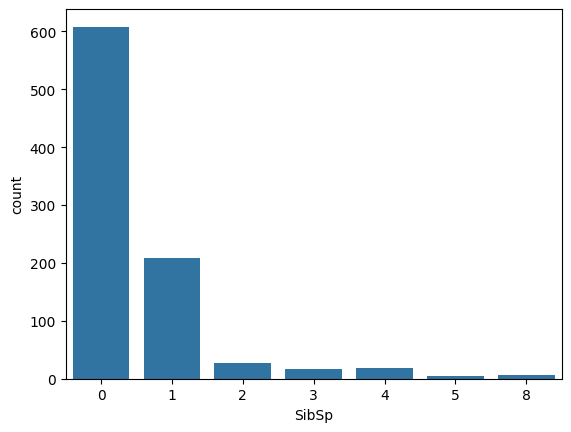

In [25]:
print(df['SibSp'].value_counts())
sb.countplot(x = df['SibSp'])

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


<Axes: xlabel='Parch', ylabel='count'>

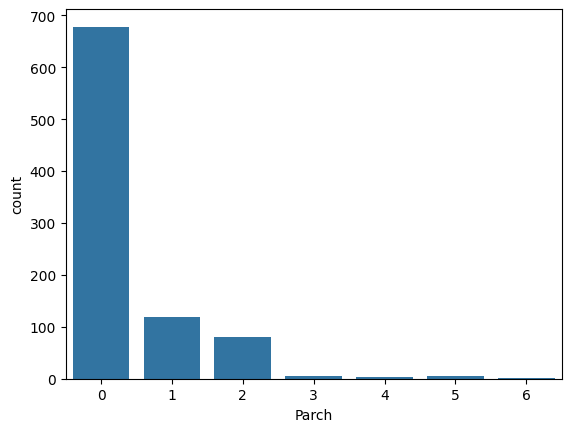

In [26]:
print(df['Parch'].value_counts())
sb.countplot(x = df['Parch'])

Embarked
S    72.502806
C    18.855219
Q     8.641975
Name: count, dtype: float64


<Axes: xlabel='Embarked', ylabel='count'>

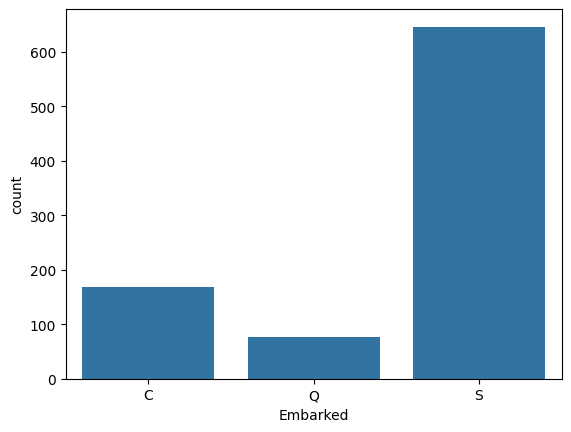

In [27]:
print((df['Embarked'].value_counts()/891)*100)
sb.countplot(x = df['Embarked'])

/tmp/ipython-input-2332120235.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df['Age'])


0.45956263424701577
0.9865867453652877


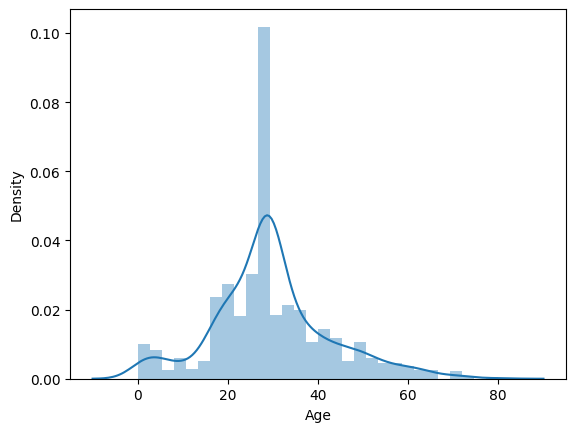

In [28]:
# age
sb.distplot(df['Age'])
print(df['Age'].skew())
print(df['Age'].kurt())

/tmp/ipython-input-875955211.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df['Age'])


0.45956263424701577
0.9865867453652877


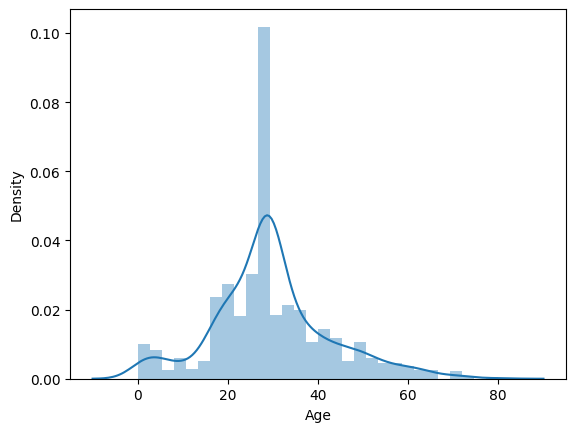

In [29]:
sb.distplot(df['Age'])
print(df['Age'].skew())
print(df['Age'].kurt())

<Axes: xlabel='Age'>

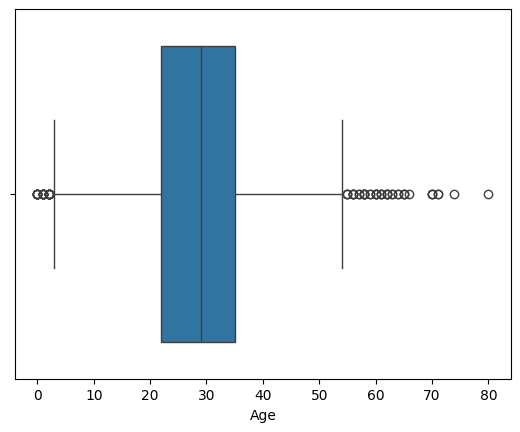

In [30]:
sb.boxplot(x =df['Age'])


In [31]:
print(df[(df['Age'] > 60) & (df['Age']<70)].shape[0])
print(df[(df['Age'] >= 70) & (df['Age']<=75)].shape[0])
print(df[(df['Age'] > 75)].shape[0])

15
6
1


/tmp/ipython-input-3009879438.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df['Fare'])


<Axes: xlabel='Fare', ylabel='Density'>

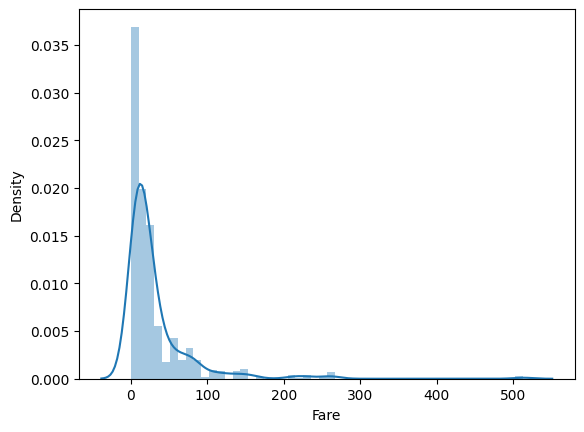

In [32]:
sb.distplot(df['Fare'])

In [33]:
print(df['Fare'].skew())
print(df['Fare'].kurt())

4.787316519674893
33.39814088089868


<Axes: xlabel='Fare'>

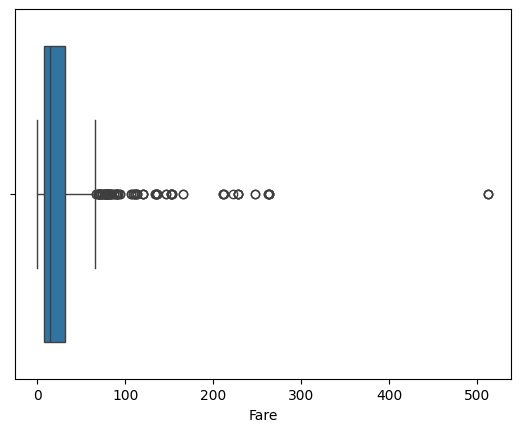

In [34]:
sb.boxplot(x = df['Fare'])

In [35]:
print(df[(df['Fare'] >= 200) & (df['Fare'] <= 300)].shape[0])
print(df[(df['Fare'] > 300)].shape[0])

17
3


In [36]:
#Multivariate Analysis

Pclass,1,2,3
Survived,,,
0,15.0,18.0,68.0
1,40.0,25.0,35.0


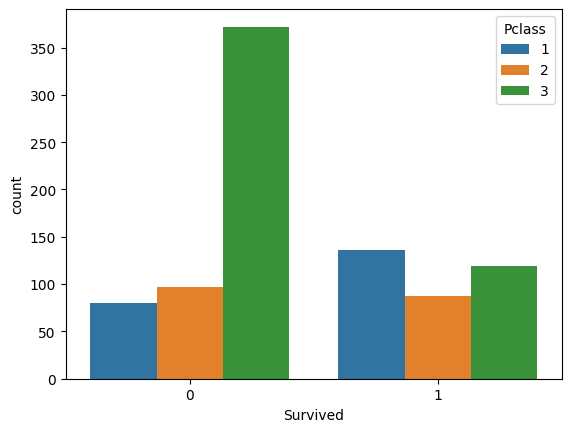

In [37]:
#Survival with pclass
sb.countplot(x = df['Survived'], hue = df['Pclass'])
pd.crosstab(df['Survived'],df['Pclass']).apply(lambda r : round((r/r.sum())*100), axis = 1)

Sex,female,male
Survived,,
0,15.0,85.0
1,68.0,32.0


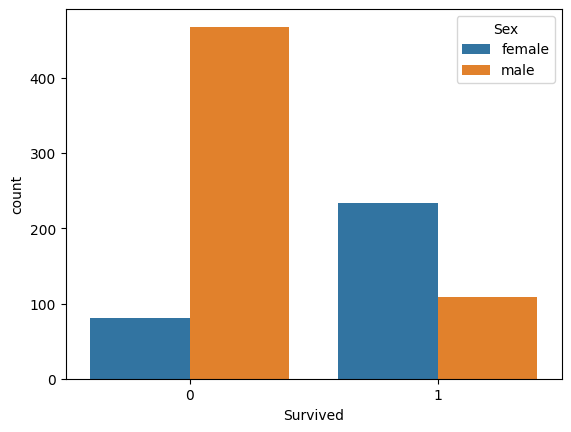

In [38]:
#Survival with sex
sb.countplot(x = df['Survived'], hue = df['Sex'])
pd.crosstab(df['Survived'],df['Sex']).apply(lambda r : round((r/r.sum())*100), axis = 1)

Survived,0,1
Embarked,,
C,45.0,55.0
Q,61.0,39.0
S,66.0,34.0


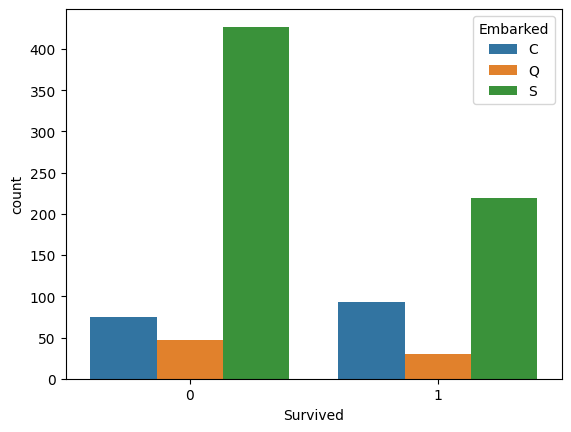

In [39]:
#Survival with Embarked
sb.countplot(x = df['Survived'], hue = df['Embarked'])
pd.crosstab(df['Embarked'], df['Survived']).apply(lambda r : round((r/r.sum())*100), axis = 1)

/tmp/ipython-input-1189506004.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df[df['Survived'] == 0]['Age'])
/tmp/ipython-input-1189506004.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df[df['Survived'] == 1]['Age'])


<Axes: xlabel='Age', ylabel='Density'>

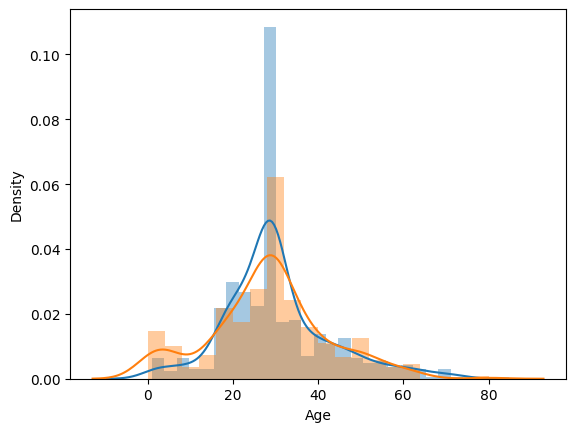

In [40]:
sb.distplot(df[df['Survived'] == 0]['Age'])
sb.distplot(df[df['Survived'] == 1]['Age'])

/tmp/ipython-input-2580253721.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df[df['Survived'] == 0]['Fare'])
/tmp/ipython-input-2580253721.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df[df['Survived'] == 1]['Fare'])


<Axes: xlabel='Fare', ylabel='Density'>

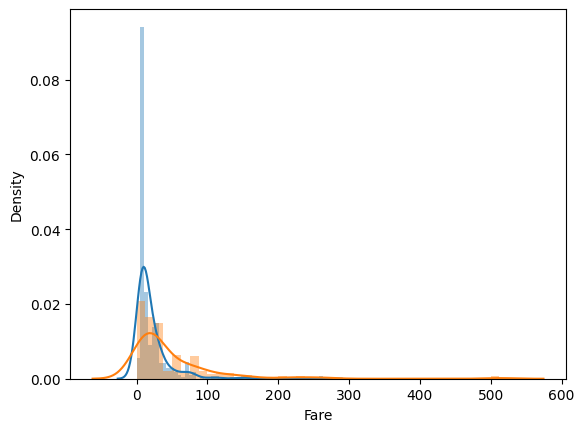

In [41]:
sb.distplot(df[df['Survived'] == 0]['Fare'])
sb.distplot(df[df['Survived'] == 1]['Fare'])

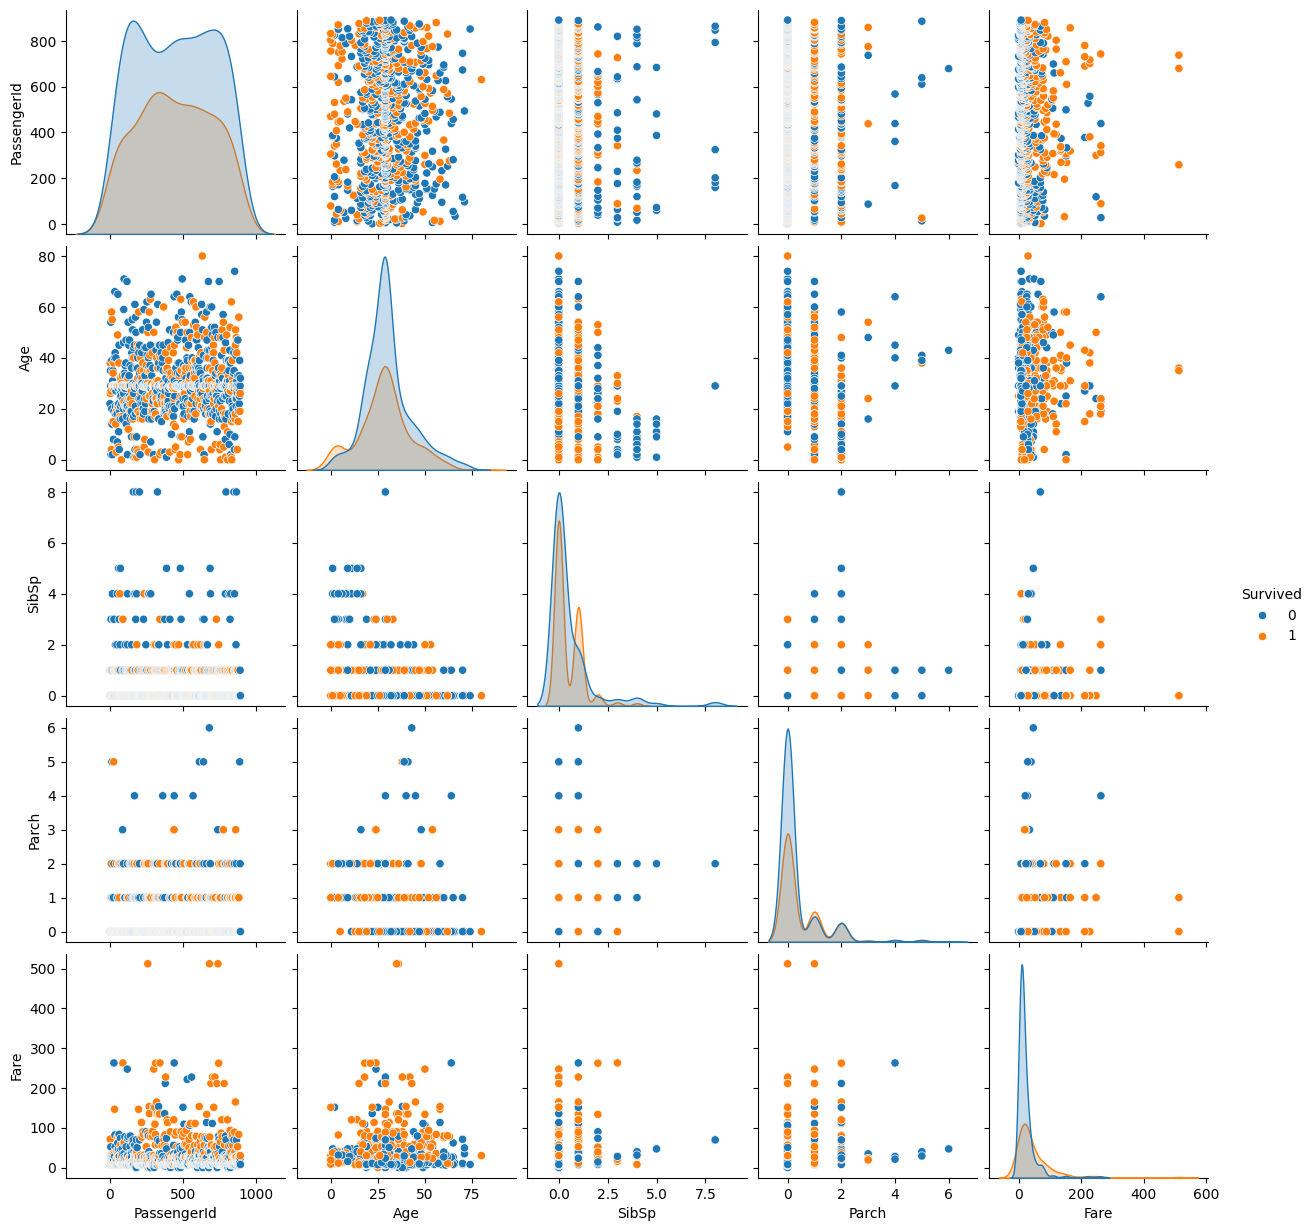

In [42]:
sb.pairplot(df, hue = 'Survived')

<Axes: >

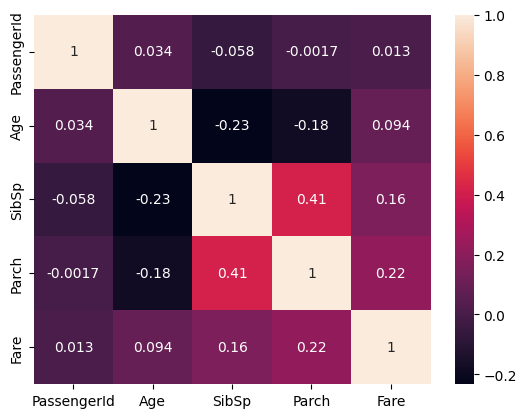

In [43]:
sb.heatmap(df.corr(numeric_only=True), annot=True)

In [44]:
# Feature Engineering

df['family_size'] = df['SibSp'] + df['Parch']

In [45]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size
90,91,0,3,"Christmann, Mr. Emil",male,29,0,0,343276,8.0500,S,0
95,96,0,3,"Shorney, Mr. Charles Joseph",male,29,0,0,374910,8.0500,S,0
181,182,0,2,"Pernot, Mr. Rene",male,29,0,0,SC/PARIS 2131,15.0500,C,0
309,310,1,1,"Francatelli, Miss. Laura Mabel",female,30,0,0,PC 17485,56.9292,C,0
161,162,1,2,"Watt, Mrs. James (Elizabeth ""Bessie"" Inglis Mi...",female,40,0,0,C.A. 33595,15.7500,S,0


In [46]:
def family_type(number):
  if number == 0:
    return 'Alone'
  elif number > 0 and number <= 4:
    return 'Medium'
  else:
    return 'Large'

In [47]:
df['family_type'] = df['family_size'].apply(family_type)

In [48]:
df.drop(columns = ['SibSp', 'Parch', 'family_size'], inplace = True)

In [49]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,family_type
0,1,0,3,"Braund, Mr. Owen Harris",male,22,A/5 21171,7.2500,S,Medium
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,PC 17599,71.2833,C,Medium
2,3,1,3,"Heikkinen, Miss. Laina",female,26,STON/O2. 3101282,7.9250,S,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,113803,53.1000,S,Medium
4,5,0,3,"Allen, Mr. William Henry",male,35,373450,8.0500,S,Alone
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,211536,13.0000,S,Alone
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,112053,30.0000,S,Alone
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29,W./C. 6607,23.4500,S,Medium
889,890,1,1,"Behr, Mr. Karl Howell",male,26,111369,30.0000,C,Alone


In [50]:
pd.crosstab(df['family_type'], df['Survived']).apply(lambda r : round((r/r.sum())*100), axis = 1)

Survived,0,1
family_type,,
Alone,70.0,30.0
Large,85.0,15.0
Medium,44.0,56.0


# Detection Outliers
**Numerical Data**
- if the data is following normal distribution anything beyond 3SD - mean +3SD can be considered as an outlier.

- if the data does not follow normal disritbution, using boxplot we can eliminate points beyond (Q1 -1.5*IQR)
 and (Q3 + 1.5*IQR)

In [51]:
#handling outliers in age(Atmost normal)

df = df[df['Age'] < (df['Age'].mean() + 3* df['Age'].std())]
df.shape

(884, 10)

In [52]:
#handling outlier from Fare column

#Fingding quartiles

Q1 = np.percentile(df['Fare'], 25)
Q3 = np.percentile(df['Fare'], 75)

outlier_low = Q1 - 1.5*(Q3-Q1)

outlier_high = Q3 + 1.5*(Q3-Q1)

df = df[(df['Fare'] > outlier_low) & (df['Fare']<outlier_high)]


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 769 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  769 non-null    int64   
 1   Survived     769 non-null    category
 2   Pclass       769 non-null    category
 3   Name         769 non-null    object  
 4   Sex          769 non-null    category
 5   Age          769 non-null    int64   
 6   Ticket       769 non-null    object  
 7   Fare         769 non-null    float64 
 8   Embarked     769 non-null    category
 9   family_type  769 non-null    object  
dtypes: category(4), float64(1), int64(2), object(3)
memory usage: 45.6+ KB


In [61]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,family_type
459,460,0,3,"O'Connor, Mr. Maurice",male,29,371060,7.7500,Q,Alone
767,768,0,3,"Mangan, Miss. Mary",female,30,364850,7.7500,Q,Alone
513,514,1,1,"Rothschild, Mrs. Martin (Elizabeth L. Barrett)",female,54,PC 17603,59.4000,C,Medium
562,563,0,2,"Norman, Mr. Robert Douglas",male,28,218629,13.5000,S,Alone
411,412,0,3,"Hart, Mr. Henry",male,29,394140,6.8583,Q,Alone


In [66]:
# one hot encoding
df.sample(4)

#cols to be transformed are Pclass, Sex, Embarked, family_type
df = pd.get_dummies(data = df, columns = ['Pclass', 'Sex', 'Embarked','family_type'], drop_first=True)

In [68]:
df

,PassengerId,Survived,Name,Age,Ticket,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,family_type_Large,family_type_Medium
0,1,0,"Braund, Mr. Owen Harris",22,A/5 21171,7.2500,False,True,True,False,True,False,True
2,3,1,"Heikkinen, Miss. Laina",26,STON/O2. 3101282,7.9250,False,True,False,False,True,False,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35,113803,53.1000,False,False,False,False,True,False,True
4,5,0,"Allen, Mr. William Henry",35,373450,8.0500,False,True,True,False,True,False,False
5,6,0,"Moran, Mr. James",29,330877,8.4583,False,True,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,"Montvila, Rev. Juozas",27,211536,13.0000,True,False,True,False,True,False,False
887,888,1,"Graham, Miss. Margaret Edith",19,112053,30.0000,False,False,False,False,True,False,False
888,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",29,W./C. 6607,23.4500,False,True,False,False,True,False,True
889,890,1,"Behr, Mr. Karl Howell",26,111369,30.0000,False,False,True,False,False,False,False


<Axes: >

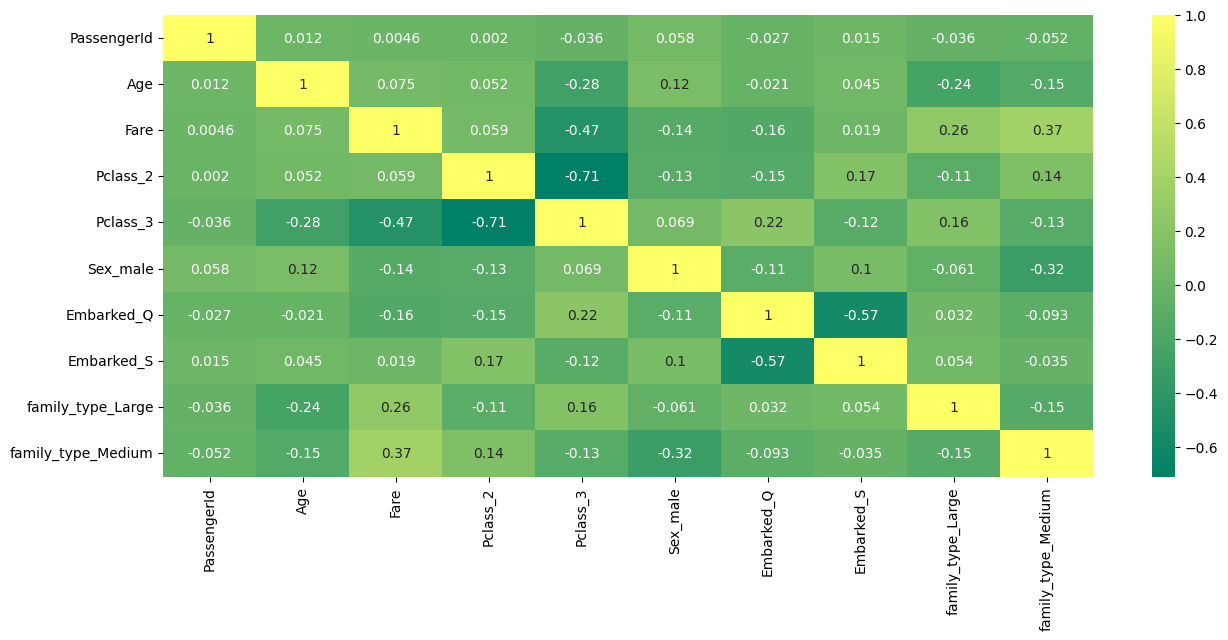

In [67]:
plt.figure(figsize= (15, 6))
sb.heatmap(df.corr(numeric_only=True), cmap = 'summer', annot=True)

# Drawing Conclusions
- Chance of female survival is higher than male survival

- Travelling in Pclass 3 was deadliest

- Somehow, people going to C survived more

- People in the age range of 20 to 40 had a higher chance of not surviving

- People travelling with smaller families had a higher chance of surviving the accident in comparison to people with large families and travelling alone